In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

## Deep dive into our dataset.

When analysing the dataset from `FibonacciModDataset` in our `model_dim_4_layer_3.py` we noticed that loss for evulate set is less than the loss for training set, which is quite the opposite.

In [12]:
from script.model_dim_4_layer_3 import FibonacciModDataset
from torch.utils.data import DataLoader, random_split


seq_len = 20
batch_size = 6
vocab_size=10
generated_ds = FibonacciModDataset(num_samples=25000, mod=vocab_size, seq_len=seq_len)

train_size = int(0.8 * len(generated_ds))
test_size = len(generated_ds) - train_size
train_ds, test_ds = random_split(generated_ds, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_ds, batch_size=batch_size, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

c = 0

for x, y in train_ds:
    if c >= 5:
        break
    print(x, y)

    c += 1



tensor([9, 9, 8, 7, 5, 2, 7, 9, 6, 5, 1, 6, 7, 3, 0, 3, 3, 6, 9, 5]) tensor([9, 8, 7, 5, 2, 7, 9, 6, 5, 1, 6, 7, 3, 0, 3, 3, 6, 9, 5, 4])
tensor([3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1, 5, 6, 1, 7, 8, 5, 3]) tensor([1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1, 5, 6, 1, 7, 8, 5, 3, 8])
tensor([9, 5, 4, 9, 3, 2, 5, 7, 2, 9, 1, 0, 1, 1, 2, 3, 5, 8, 3, 1]) tensor([5, 4, 9, 3, 2, 5, 7, 2, 9, 1, 0, 1, 1, 2, 3, 5, 8, 3, 1, 4])
tensor([1, 0, 1, 1, 2, 3, 5, 8, 3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4]) tensor([0, 1, 1, 2, 3, 5, 8, 3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1])
tensor([3, 3, 6, 9, 5, 4, 9, 3, 2, 5, 7, 2, 9, 1, 0, 1, 1, 2, 3, 5]) tensor([3, 6, 9, 5, 4, 9, 3, 2, 5, 7, 2, 9, 1, 0, 1, 1, 2, 3, 5, 8])



Basically we are generating random shamples and then using sliding window to generate shamples from those.
Now the randomness is in the start_idx, we want to see the dublicates pair to better understand it.
So we want to see the dublicates in both train and test set pais because, if the model has already seen
the data then it will try to find a shortcut

In [13]:
import torch

print(len(train_ds))
print(len(test_ds))
print(len(train_ds) + len(test_ds)) # that should correspond to the shamples provided.

pairs = []
for x, y in train_ds:
    x = torch.cat((x, y[-1: ]))
    pairs.append(x)
print(pairs[0: 4])
print(len(pairs)) # just making sure the math match
print(len(pairs[0]))


20000
5000
25000
[tensor([9, 9, 8, 7, 5, 2, 7, 9, 6, 5, 1, 6, 7, 3, 0, 3, 3, 6, 9, 5, 4]), tensor([3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1, 5, 6, 1, 7, 8, 5, 3, 8]), tensor([9, 5, 4, 9, 3, 2, 5, 7, 2, 9, 1, 0, 1, 1, 2, 3, 5, 8, 3, 1, 4]), tensor([1, 0, 1, 1, 2, 3, 5, 8, 3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1])]
20000
21


## Algorithmic thinking for fun!

We need to find the dublicate pairs, now so what I want to do is, it's not just about dublicate pairs that we are finding but we are finding pairs in a fibonachi sequence. 

<b>Not useful for our case, becasue of character of fib</b>

In [14]:
arr = torch.cat(pairs, dim=0).tolist()

arr = arr[0: 63]
pair_map = []
for i in range(0, len(arr), 3):
    ''' 
        Here since its a fibonachi sequence so a + b = c characterstics
        so its not a common pair problem.
    '''
    a = arr[i]
    b = arr[i + 1]

    see_pairs = next((item for item in pair_map if item.get('a') + item.get('b') == a+ b ), None)

    if see_pairs is None: # if not exists then append there.
        pair_map.append({
            'a': a,
            'b': b,
            'f': 1
        })
    c1 = a + b
    for j in range(i, len(arr), 3):
        try:
            ca = arr[j + 3] # because we skip that output part.
            cb = arr[j + 4]
            c2 = ca + cb
            if c1 == c2:
                # if found pairs then we are going to increase the frequency.
                ''' If we are looking for dub of this see_pairs particular pairs then
                 if course we can increment that see_pairs and go on '''
                see_pairs['f'] += 1
        except Exception: # we might go off limit for sure.
            pass
result = []
for i in range(0, len(pair_map)):
    if pair_map[i].get('f') > 1:
        result.append(pair_map[i])

print(arr)
print(result) # this is just for getting idea nth more.

# Algorithm takes very long time to run not so effective here. 


[9, 9, 8, 7, 5, 2, 7, 9, 6, 5, 1, 6, 7, 3, 0, 3, 3, 6, 9, 5, 4, 3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1, 5, 6, 1, 7, 8, 5, 3, 8, 9, 5, 4, 9, 3, 2, 5, 7, 2, 9, 1, 0, 1, 1, 2, 3, 5, 8, 3, 1, 4]
[{'a': 7, 'b': 5, 'f': 2}, {'a': 5, 'b': 1, 'f': 2}, {'a': 7, 'b': 3, 'f': 2}, {'a': 9, 'b': 5, 'f': 4}, {'a': 1, 'b': 7, 'f': 2}]


## Dublicates in 100 pairs.

Total possible pairs: 100
Pairs found: 60
Pairs never seen: 40

  (0, 1) -> 16x
  (0, 3) -> 16x
  (0, 7) -> 17x
  (0, 9) -> 17x
  (1, 0) -> 16x
  (1, 1) -> 17x
  (1, 2) -> 17x
  (1, 4) -> 17x
  (1, 5) -> 17x
  (1, 6) -> 16x
  (1, 7) -> 17x
  (1, 9) -> 17x
  (2, 3) -> 17x
  (2, 5) -> 16x
  (2, 7) -> 17x
  (2, 9) -> 16x
  (3, 0) -> 16x
  (3, 1) -> 17x
  (3, 2) -> 16x
  (3, 3) -> 16x
  (3, 5) -> 17x
  (3, 6) -> 16x
  (3, 7) -> 17x
  (3, 8) -> 17x
  (4, 1) -> 17x
  (4, 3) -> 17x
  (4, 5) -> 17x
  (4, 9) -> 16x
  (5, 1) -> 16x
  (5, 2) -> 17x
  (5, 3) -> 17x
  (5, 4) -> 16x
  (5, 6) -> 17x
  (5, 7) -> 16x
  (5, 8) -> 17x
  (5, 9) -> 17x
  (6, 1) -> 17x
  (6, 5) -> 17x
  (6, 7) -> 16x
  (6, 9) -> 16x
  (7, 0) -> 17x
  (7, 2) -> 16x
  (7, 3) -> 16x
  (7, 4) -> 17x
  (7, 5) -> 17x
  (7, 7) -> 17x
  (7, 8) -> 17x
  (7, 9) -> 17x
  (8, 1) -> 17x
  (8, 3) -> 17x
  (8, 5) -> 17x
  (8, 7) -> 17x
  (9, 0) -> 17x
  (9, 1) -> 16x
  (9, 3) -> 16x
  (9, 4) -> 17x
  (9, 5) -> 16x
  (9, 6) -> 17x
  (9, 8)

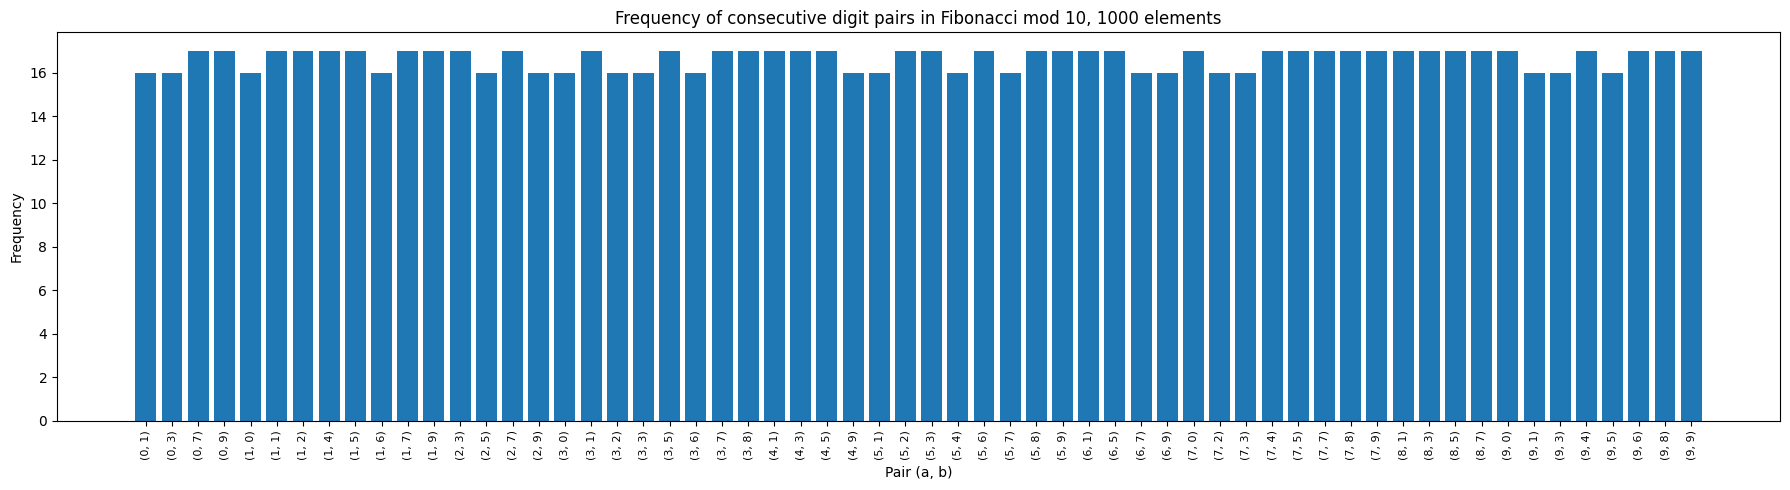

In [21]:
import matplotlib.pyplot as plt
from collections import Counter


def count_digit_pairs(mod=10, seq_length=1000):
    seq = [1, 1]
    while len(seq) < seq_length:
        seq.append((seq[-1] + seq[-2]) % mod)
    
    '''
        total possible comibation (a, b) = n*n = 100 a and b both can range from 0 to 9
    '''
    # count consecutive digit pairs (a, b)
    pair_counts = Counter()
    for i in range(len(seq) - 1):
        a, b = seq[i], seq[i+1]
        pair_counts[(a, b)] += 1
    
    print(f"Total possible pairs: {mod * mod}")
    print(f"Pairs found: {len(pair_counts)}")
    print(f"Pairs never seen: {mod*mod - len(pair_counts)}")
    print()
    for pair, count in sorted(pair_counts.items()):
        print(f"  ({pair[0]}, {pair[1]}) -> {count}x")

    labels = [str(pair) for pair in sorted(pair_counts)]
    values = [pair_counts[pair] for pair in sorted(pair_counts)]
    
    plt.figure(figsize=(18, 5))
    plt.bar(labels, values)
    plt.xticks(rotation=90, fontsize=8)
    plt.xlabel("Pair (a, b)")
    plt.ylabel("Frequency")
    plt.title("Frequency of consecutive digit pairs in Fibonacci mod 10, 1000 elements")
    plt.tight_layout()
    plt.show()

count_digit_pairs(mod=10, seq_length=1000)